# Paper Supplement: Reproducibility Notebook

This notebook accompanies the manuscript as supplementary material.

**How to use**
1. Create a Python environment (see `environment.yml` / `requirements.txt`).
2. Place required input data under the `data/` folder, preserving relative paths used below.
3. Run cells from top to bottom.

**Provenance**
- Python: 3.11.10
- Generated: for GitHub archival


In [14]:
from pathlib import Path

# Project directories (relative paths for portability)
ROOT = Path.cwd()
DATA = ROOT / "data"
OUTPUTS = ROOT / "outputs"
FIGURES = ROOT / "figures"

for d in [DATA, OUTPUTS, FIGURES]:
    d.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("DATA:", DATA)


ROOT: C:\Users\oxyli\supplement-main
DATA: C:\Users\oxyli\supplement-main\data


In [15]:
import sys
sys.path.append('DATA')
import pymethods as pma
from pymethods import pyplot as plt
import pathlib as pt
import numpy as np
from time import time
import matplotlib


In [16]:
%matplotlib inline

In [17]:
import os
import pandas as pd
""" code used for large scale automated work
def convert_obj_to_data_direct(obj_path, save_path): #obj file (Rhino curve) to data file 
    with open(obj_path, 'r') as f:
        lines = [line.strip() for line in f if line.startswith('v ')]
    
    with open(save_path, 'w') as f:
        f.write("# LkebCurve Data File version 2.0\n")
        f.write("ASCII\n")
        f.write("Curve Type: double\n")
        f.write("Dimension: 3\n")
        f.write(f"Number of points: {len(lines)}\n")
        f.write("Closed: 0\nND: 0\n")
        f.write("Name: class LkebCurve<class LkebPoint<double,class LkebTuple3> >\n")
        f.write("Attributes: 0\nSpace:\n")
        f.write("1.0000000000000000e+000 0.0000000000000000e+000 0.0000000000000000e+000 "
                "0.0000000000000000e+000 0.0000000000000000e+000 1.0000000000000000e+000 "
                "0.0000000000000000e+000 0.0000000000000000e+000 0.0000000000000000e+000 "
                "0.0000000000000000e+000 0.0000000000000000e+000 1.0000000000000000e+000 "
                "0.0000000000000000e+000\n")
        f.write("Data:\n")

        for line in lines:
            _, x, y, z = line.split()
            f.write(f"{float(x):.16e} {float(y):.16e} {float(z):.16e}\n")

    print(f"✓ Saved: {save_path}")


#csv_path = r"C:DATA/oct_segmentation/case_list.csv"  
#obj_root =  r"C:DATA/imaging/obj"
#save_root =  r"C:DATA/imaging/centerline data"

df = pd.read_csv(csv_path)


for _, row in df.iterrows():
    case_id = row["CaseID"].strip()
    vessel = row["Vessel"].strip()
    prefix = f"{case_id}_{vessel}"
    folder_name = f"{case_id} {vessel}"
    save_folder = os.path.join(save_root, folder_name)
    os.makedirs(save_folder, exist_ok=True)

    # (1) main → centerline1.data
    main_path = os.path.join(obj_root, f"{prefix}_main.obj")
    main_out = os.path.join(save_folder, "centerline1.data")
    if os.path.exists(main_path):
        convert_obj_to_data_direct(main_path, main_out)
    else:
        print(f"✗ main OBJ missing: {main_path}")

    # (2) bifur → centerline2.data
    bifur_path = os.path.join(obj_root, f"{prefix}_bifur.obj")
    bifur_out = os.path.join(save_folder, "centerline2.data")
    if os.path.exists(bifur_path):
        convert_obj_to_data_direct(bifur_path, bifur_out)
    else:
        print(f"✗ bifur OBJ missing: {bifur_path}")

"""

' code used for large scale automated work\ndef convert_obj_to_data_direct(obj_path, save_path): #obj file (Rhino curve) to data file \n    with open(obj_path, \'r\') as f:\n        lines = [line.strip() for line in f if line.startswith(\'v \')]\n\n    with open(save_path, \'w\') as f:\n        f.write("# LkebCurve Data File version 2.0\n")\n        f.write("ASCII\n")\n        f.write("Curve Type: double\n")\n        f.write("Dimension: 3\n")\n        f.write(f"Number of points: {len(lines)}\n")\n        f.write("Closed: 0\nND: 0\n")\n        f.write("Name: class LkebCurve<class LkebPoint<double,class LkebTuple3> >\n")\n        f.write("Attributes: 0\nSpace:\n")\n        f.write("1.0000000000000000e+000 0.0000000000000000e+000 0.0000000000000000e+000 "\n                "0.0000000000000000e+000 0.0000000000000000e+000 1.0000000000000000e+000 "\n                "0.0000000000000000e+000 0.0000000000000000e+000 0.0000000000000000e+000 "\n                "0.0000000000000000e+000 0.000000000

In [18]:
from pymethods import parse
#patientID = 231 (example)
mm_per_frame = 0.200
path_angio = ROOT / "data" / "sample" / "centerlines"
path_oct = ROOT / "data" / "sample" / "OCT"

# notice how we use the CenterlinesA to parse the centerlines. This ensures that the centerlines are oriented correctly
folder_angio = pma.parse.angiography.CenterlinesB(path_angio)
folder_oct = pma.parse.ivoct.Folder(path_oct)
#try:
    #folder_oct.load()
#except:
folder_oct.parse(processors=1)

INFO:root:Extracting Contours and Landmark Data from Images


done


([Contour([[629.44801865, 629.23589744, 629.13286713, ..., 629.69044289,
            629.5995338 , 629.44801865],
           [586.004662  , 586.89044289, 587.92027972, ..., 584.60606061,
            585.25874126, 586.004662  ],
           [  0.        ,   0.        ,   0.        , ...,   0.        ,
              0.        ,   0.        ]]),
  Contour([[632.48531469, 632.804662  , 633.04009324, ..., 631.7981352 ,
            632.12867133, 632.48531469],
           [579.92867133, 580.58135198, 581.28997669, ..., 578.53752914,
            579.28531469, 579.92867133],
           [  0.        ,   0.        ,   0.        , ...,   0.        ,
              0.        ,   0.        ]]),
  Contour([[633.16876457, 633.08484848, 633.23403263, ..., 633.53240093,
            633.38088578, 633.16876457],
           [582.97016317, 583.97948718, 584.99114219, ..., 581.24195804,
            582.02144522, 582.97016317],
           [  0.        ,   0.        ,   0.        , ...,   0.        ,
           

let us first extract the necessary angiography data

## Orienting the centerlines

In [19]:
centerline_main, centerline_bifur = folder_angio.parse().values()

We must note that the CenterlinesA and the CenterlinesB class both contain a parse method which orients the centerlines, bifCenterlines 1 and 2 and centerlines 1 and 2 respectively. We see that the centerlines are now ordered distal to proximal

[[  86.49558258   86.37478205   86.25124539 ...   38.88610066
    38.74598769   38.61184311]
 [-205.01507568 -205.02039081 -205.04152037 ... -160.26647057
  -160.20144702 -160.12051392]
 [ 412.65661621  412.54606364  412.44569463 ...  492.21105954
   492.25477072  492.29919434]]
[[  45.72343063   45.74618069   45.76755848 ...   53.02066128
    53.01185983   53.00239944]
 [-188.50987244 -188.49298118 -188.4750466  ... -171.76491191
  -171.73865343 -171.71232605]
 [ 473.64343262  473.64134123  473.64100063 ...  488.34891199
   488.35055515  488.35018921]]


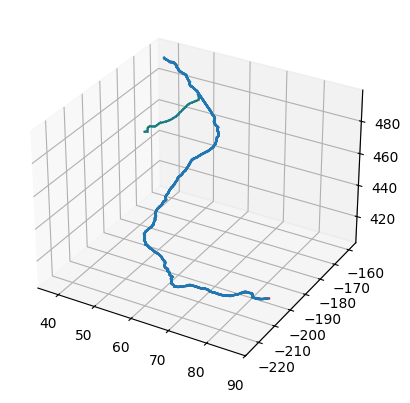

In [20]:
centerline_main.plot3d('r')
main_tangents = centerline_main.transport_frames()[:, :, -1]
print(centerline_main)
print(centerline_bifur)

centerline_bifur.plot3d('g')
transportFrames = centerline_main.transport_frames()

for i, (center, frame) in enumerate(zip(centerline_main.T, transportFrames)):
    pma.arrays.ColumnVector(frame[:, -1]).quiver3d(origin=center)
       


transportFrames = centerline_bifur.transport_frames()
for i, (center, frame) in enumerate(zip(centerline_bifur.T, transportFrames)):
    if i%50 == 0:
        pma.arrays.ColumnVector(frame[:, -1]).quiver3d(origin=center)

plt.show()

Support for third party widgets will remain active for the duration of the session. To disable support:

Support for third party widgets will remain active for the duration of the session. To disable support:

## Scaling the OCT Data

To generate our surface we need to know the spacing between each frame and the total pixels per mm per image. This is extracted externally

In [21]:
mm_per_pixel = 0.009775


We first need to scale our oct data. The ivoct.Folder object has a convenience function which performs the scaling for us and provides us with the data necessary for reconstruction

In [22]:
contours, landmark, frame_id, image_files, landmark_path = folder_oct.data_scaled(mm_per_pixel).values()
print(len(contours))
print(contours)

32
[Contour([[6.15285438, 6.1507809 , 6.14977378, ..., 6.15522408,
          6.15433544, 6.15285438],
         [5.72819557, 5.73685408, 5.74692073, ..., 5.71452424,
          5.7209042 , 5.72819557],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ]]), Contour([[6.18254395, 6.18566557, 6.18796691, ..., 6.17582677,
          6.17905776, 6.18254395],
         [5.66880276, 5.67518272, 5.68210952, ..., 5.65520435,
          5.66251395, 5.66880276],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ]]), Contour([[6.18922467, 6.18840439, 6.18986267, ..., 6.19277922,
          6.19129816, 6.18922467],
         [5.69853334, 5.70839949, 5.71828841, ..., 5.68164014,
          5.68925963, 5.69853334],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ]]), Contour([[6.21298544, 6.21150438, 6.2094309 , ..., 6.21417029,
          6.21387408, 6.21298544],
         [

# Positioning the contours

Since we are translating the contours from their centroid, to approximate the location of our artery we shall need to know where our landmark is located. We have specified the landmark as the location where the bifurcation centerline is passing through and is shown as a blue spot along the OCT image. We can do so by approximating the point perpendicular to the main centerline which lies on the bifurcation centerline for the distance specified by our landmark

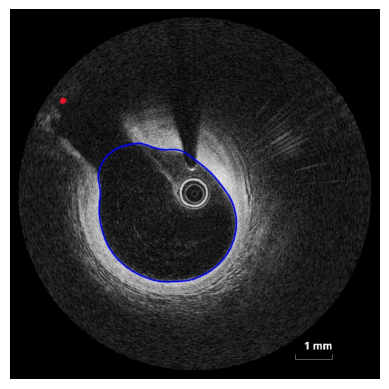

In [23]:
plt.figure()
pma.parse.ivoct.Image(landmark_path).show()
plt.show()

Support for third party widgets will remain active for the duration of the session. To disable support:

The vector which passes from the contour centroid to the landmark is given by landmark. We can obtain this distance from the bar property

In [24]:
print('the landmark vector:\n', landmark)
landmark_hat = pma.math.normalize(landmark).squeeze()
print(' the length of the landmark vector:', landmark.bar)

the landmark vector:
 [[-2.85691481]
 [-3.13019369]
 [ 0.        ]]
 the length of the landmark vector: 4.2379328390182796


Every curve has a method which calculates the point pairs at a specified distance between another curves. Bellow we show the output as the dictionary containing the point on the main centerline, the bifurcation centerline, the error and the vector fromt he main to bifur centerlines

In [25]:
perpendicularPointDict = centerline_main.findPointPairsAtPerpendicularDistance(centerline_bifur, distance=landmark.bar, resolution=0.0001)
print("the data required:\n", perpendicularPointDict)

the data required:
 {'on_main': Vector([  56.30239441, -175.75075009,  488.50295138]), 'on_input': Vector([  53.2558403 , -178.2963562 ,  487.01950073]), 'error': 0.0002540667853798695, 'vector': Vector([-3.04655411, -2.54560611, -1.48345065])}


In [26]:
pt_main, pt_bifur, error, vector = perpendicularPointDict.values()

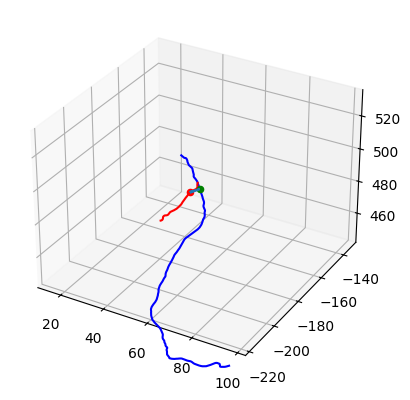

In [27]:
plt.figure_3d()
centerline_main.plot3d('b')
centerline_bifur.plot3d('r')
vector.quiver3d(origin=pt_main)
pt_main.scatter3d(color='green')
pt_bifur.scatter3d(color='red')
plt.equal_aspect_3d_centered(pt_main)
plt.show()

Originally our transport frames are not oriented along the centerline. But since we now have an approximation to of the orientation of our frames we can now orient our transport frames.

[[-0.71883458]
 [-0.6006353 ]
 [-0.35002012]]
[-8.52414433e-01  5.22866747e-01  6.93889390e-18]
[[ 0.76359595 -0.12992674 -0.63248737]
 [ 0.61673955 -0.1432824   0.7740171 ]
 [-0.19118982 -0.9811163  -0.0292789 ]]
[[ 5.22866747e-01 -8.52414433e-01  0.00000000e+00]
 [ 8.52414433e-01  5.22866747e-01  0.00000000e+00]
 [-0.00000000e+00  6.93889390e-18  1.00000000e+00]]
[[-0.73861333  0.67412933  0.        ]
 [-0.67412933 -0.73861333  0.        ]
 [ 0.          0.          1.        ]]
[[ 0.27149198  0.72543217 -0.63248737]
 [ 0.25693457  0.57869003  0.7740171 ]
 [ 0.92751104 -0.37264731 -0.0292789 ]]
12.138252993307466


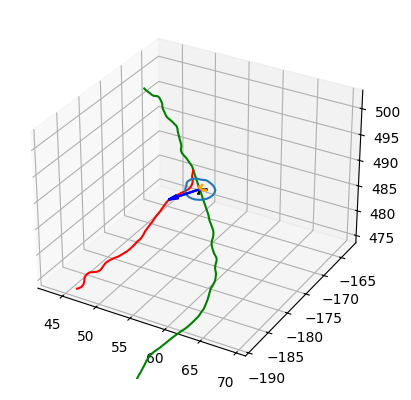

In [28]:
orientedTransportFrames, origin_id = centerline_main.oriented_transport_frames(
    pt_main, vector, landmark_hat
)
mainTransportFrames = centerline_main.transport_frames()
fig, ax=plt.figure_3d()

ax.set_xlim(350,365)
ax.set_ylim(-170,-140)
ax.set_zlim(-30,0)
centerline_main.plot3d('g')
centerline_bifur.plot3d('r')

# the now oriented transport frames
pma.arrays.Basis(orientedTransportFrames[origin_id]).quiver3d(
    origin=centerline_main[:, origin_id], color='orange'
)
ijk_self = pma.arrays.Basis(mainTransportFrames[origin_id])
Vector =  pma.arrays.ColumnVector(vector).hat
projected = Vector.project_to_plane(ijk_self[:, -1])
print(projected)
j_new = pma.math.normalize(
    projected.change_reference_frame(ijk_self)).squeeze()
print(j_new)
z_new = np.array([0, 0, 1])
ijk_new = pma.arrays.Basis(
    pma.math.normalize(pma.math.cross(j_new, z_new)), j_new, z_new
)

i_real = np.array([landmark_hat[1], landmark_hat[0], 0])
j_real = np.array([-landmark_hat[0], landmark_hat[1], 0])
ijk_real = pma.arrays.Basis(i_real, j_real, z_new)
    
newTransportFrame = np.zeros_like(mainTransportFrames[origin_id])
newTransportFrame = pma.arrays.Basis( mainTransportFrames[origin_id] @ ijk_new @ ijk_real)
print( mainTransportFrames[origin_id])
print(ijk_new)
print(ijk_real)
print(newTransportFrame)

# the now original transport frames
pma.arrays.Basis(mainTransportFrames[origin_id]).quiver3d(
    origin=centerline_main[:, origin_id], color='black'
)
vector.quiver3d(
    origin=centerline_main[:, origin_id], color='blue'
)
projected.quiver3d(
    origin=centerline_main[:, origin_id], color='yellow'
)

contour = contours[frame_id]
area = pma.math.area(contour)
print(area)
contour = mainTransportFrames[origin_id] @ (contour - contour.centroid) + centerline_main[:, origin_id, None]

contour.plot3d()

plt.equal_aspect_3d_centered(pt_main)
plt.show()

However this is not yet enough to orient our contours. We still need to ensure that the spacing between the frames is correct. To do so we estimate the fraction along the main centerline our landmark is located

In [29]:
s_location_landmark = centerline_main.s_frac[origin_id]
print(s_location_landmark)

0.8438414168979473


From here we can now approximate the fraction along the artery where the frames are located

In [30]:
frac_per_frame = mm_per_frame/centerline_main.s_tot
print(frac_per_frame)

0.0012456145671545017


Thus we can figure out the required fractions to interpolate our centerline

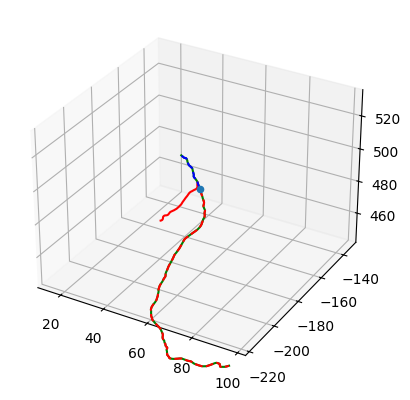

In [31]:
plt.figure_3d()
# calculate the spacing distal to the landmark
distal_half = pma.utils.gap_space(s_location_landmark, 0, frac_per_frame)
# calculate the spacing proximal to the landmark
proximal_half = pma.utils.gap_space(s_location_landmark, 1, frac_per_frame)[:-1]

#for visualiztion purposes
main_centerlin_distal = pma.arrays.Curve(centerline_main(distal_half))
main_centerlin_proximal = pma.arrays.Curve(centerline_main(proximal_half))

centerline_main.plot3d('g')
centerline_bifur.plot3d('r')

main_centerlin_distal.plot3d('r--')
main_centerlin_proximal.plot3d('b--')
centerline_main[:, origin_id].scatter3d()
plt.equal_aspect_3d_centered(pt_main)
plt.show()

We can now calculate the required arc length fraction to obtain the required centerline

In [32]:
s_req = np.concatenate(
        [distal_half, proximal_half[1:]]
)
s_req.sort()
interpolated_centerline = centerline_main(s_req)

interpolated_landmark = len(distal_half)


The portion of the centerline used can now be calculated

In [33]:
centerline_start = interpolated_landmark-frame_id
centerline_end = centerline_start + len(contours)
print(centerline_start)
print(len(contours))
print(centerline_end, interpolated_centerline.shape[-1])
# we should assert that the centerline start is greater than 0
assert centerline_start > -1
# we should assert that the amount of frames from the landmark is less than the interpolated centerline
assert centerline_end < interpolated_centerline.shape[-1]

669
32
701 802


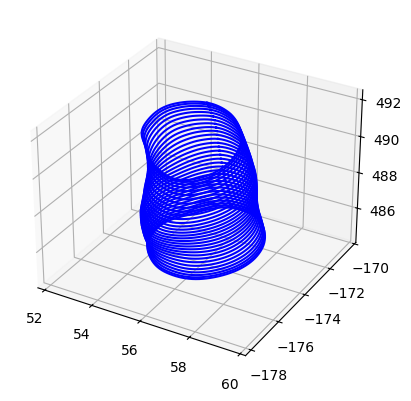

In [34]:
transportFrames, origin_id = interpolated_centerline.oriented_transport_frames(interpolated_centerline[:, interpolated_landmark, None], vector, landmark_hat)
translated_contours = []

area_array = []
mm_per_pixel = 0.009775
catheter_mm_origin = np.array([[500 * mm_per_pixel],
                               [500 * mm_per_pixel],
                               [0.0]]) 

for j, i in enumerate(range(centerline_start, centerline_end)):
    contour = contours[j]
    contour = pma.math.make_3d(contour)  # shape (3, N)

    window_size = pma.utils.make_odd(contour.shape[-1] // 100)
    contour = pma.arrays.Contour(contour).filter(window_size, 3)
    contour = contour(np.linspace(0, 1, 100))  # shape (3, 100)

    contour = contour - catheter_mm_origin  

    origin = interpolated_centerline[:, i].make_column()
    basis = transportFrames[i]

    #if j >= 99:
        #print(basis[:, -1])

    contour = (basis @ contour) + origin
    translated_contours.append(contour)
    area_array.append(pma.math.area(contour))

surface = pma.arrays.structured.CylindricalSurface.from_contours(translated_contours)
surface.interpolate_long(300)
surface = surface.filter(window_size=15)
surface = surface.interpolate_contours(100)
plt.figure_3d()
surface.plot3d()
plt.equal_aspect_3d()
plt.show()

import csv

def save_to_csv(array, file_path):
    with open(file_path, 'w', newline='') as csvfile:
        csv_writer = csv.writer(csvfile)
        csv_writer.writerow(['Value'])  # Optional: Write a header row
        csv_writer.writerow(array)

# Example usage:

#csv_file_path = f'C:DATA/F{patientID}/area_F{patientID}.csv'

#save_to_csv(area_array, csv_file_path)

# High Level API

In [35]:
surface.to_stl(OUTPUTS / "sample_artery.stl")

In [36]:
import pandas as pd
frame_start = 1
frame_end = len(contours)
fotv = np.zeros((frame_end-frame_start+1,7))
for j, i in enumerate(range(centerline_start + frame_start -1 , centerline_start + frame_end)):
    origin = interpolated_centerline[:, i]
    basis = transportFrames[i]
    tangent_vector = basis[:,-1]
    print(tangent_vector)
    frameid_origin_tangent_vector = np.concatenate(([j+1], 0.001*origin, tangent_vector), axis = 0)
    fotv[j,:] = frameid_origin_tangent_vector
df = pd.DataFrame(fotv, columns=['Frame', 'B', 'C','D','E','F','G'])


# CSV
df.to_csv(OUTPUTS / "sample_frames.csv", index=False)




[-0.63248742  0.77401706 -0.02927895]
[-0.63248743  0.77401706 -0.02927868]
[-0.63248742  0.77401707 -0.02927875]
[-0.63248742  0.77401706 -0.02927889]
[-0.63248743  0.77401705 -0.02927893]
[-0.63248743  0.77401705 -0.02927889]
[-0.63248742  0.77401706 -0.02927887]
[-0.63248738  0.7740171  -0.02927888]
[-0.63248737  0.7740171  -0.02927889]
[-0.63248748  0.77401702 -0.02927886]
[-0.63248761  0.77401691 -0.0292788 ]
[-0.63248752  0.77401698 -0.02927884]
[-0.63248703  0.77401737 -0.02927903]
[-0.63248665  0.77401768 -0.02927919]
[-0.63248742  0.77401706 -0.02927888]
[-0.63248951  0.77401539 -0.02927803]
[-0.63249006  0.77401494 -0.02927781]
[-0.63248533  0.77401874 -0.02927972]
[-0.63247779  0.77402478 -0.02928277]
[-0.63248033  0.77402274 -0.02928175]
[-0.63250383  0.7740039  -0.02927224]
[-0.63252708  0.77398526 -0.02926283]
[-0.6324969   0.77400946 -0.02927505]
[-0.63239159  0.77409389 -0.02931764]
[-0.63234233  0.77413338 -0.02933757]
[-0.63255112  0.77396598 -0.0292531 ]
[-0.63295322